In [1]:
import experiment_utils
from experiment_utils import config

config.experiment_name = "inHomo_complexHelmholtz_dirichlet_1d"
config.target = "jmlr"
config.debug_mode = True

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import probnum as pn

import linpde_gp
from linpde_gp.problems.pde import get_1d_dirichlet_boundary_observations
from linpde_gp.utils import to_real2, from_real2
from scipy.ndimage import gaussian_filter1d

[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [3]:
class HelmholtzBeliefPlotter:

    COLORS = {
        "real_belief": "C0",
        "imag_belief": "C4",
        "real_truth": "C1",
        "imag_truth": "C5",
        "bc": "C2",
        "pde_collocation": "C3",
    }

    SAMPLE_ALPHA = 0.08
    SAMPLE_LW = 0.5
    BAND_ALPHA = 0.2
    NUM_SAMPLES = 10
    TRUTH_LINESTYLE = "--"
    TRUTH_LW = 1.5
    MEAN_LW = 1.5
    MARKER_SIZE = 80
    RNG_SEED = 24

    def __init__(self, bvp):
        self._bvp = bvp
        self._plt_grid = np.linspace(*bvp.pde.domain, 201)

        self._is_real2 = getattr(bvp.pde, "complex_representation", "none") == "real2"
        self._is_complex = (
            np.iscomplex(bvp.pde.k_squared)
            or (bvp.solution is not None and np.iscomplexobj(bvp.solution(self._plt_grid[0])))
            or self._is_real2
        )

    # Core decomposition helpers

    def _decompose(self, vals, output_shape=None):
        """Split array into (real, imag) parts."""
        if self._is_real2 and (
            (output_shape is not None and output_shape == (2,))
            or (vals.ndim >= 1 and vals.shape[-1] == 2)
        ):
            return vals[..., 0], vals[..., 1]
        return np.real(vals), np.imag(vals)

    def _decompose_samples(self, samples):
        """Decompose sample tensor of shape (num_samples, N, D) → (N, num_samples) per part."""
        if self._is_real2 and samples.shape[-1] == 2:
            return samples[..., 0].T, samples[..., 1].T  # each (N, num_samples)
        return np.real(samples).squeeze(-1).T, np.imag(samples).squeeze(-1).T

    def _plot_gp_component(self, ax, x, mean, std, samples, color, label):
        ax.plot(x, mean, color=color, label=label, lw=self.MEAN_LW)
        ax.fill_between(
            x,
            mean - 2 * std,
            mean + 2 * std,
            color=color,
            alpha=self.BAND_ALPHA,
        )
        for i in range(samples.shape[1]):
            ax.plot(
                x, samples[:, i],
                color=color, alpha=self.SAMPLE_ALPHA, lw=self.SAMPLE_LW,
            )

    def _plot_complex_belief(self, ax, x, mean, std, samples, label_base, plot_part):
        mean_re, mean_im = self._decompose(mean)
        std_re, std_im = self._decompose(std)
        samp_re, samp_im = self._decompose_samples(samples)

        if plot_part in ("real", "both"):
            self._plot_gp_component(
                ax, x, mean_re, std_re, samp_re,
                self.COLORS["real_belief"],
                rf"$\mathrm{{Re}}[{label_base}]$",
            )
        if plot_part in ("imag", "both"):
            self._plot_gp_component(
                ax, x, mean_im, std_im, samp_im,
                self.COLORS["imag_belief"],
                rf"$\mathrm{{Im}}[{label_base}]$",
            )

    def _plot_truth_line(self, ax, x, vals, plot_part):
        sol_re, sol_im = self._decompose(vals)
        if plot_part in ("real", "both"):
            ax.plot(
                x, sol_re, color=self.COLORS["real_truth"],
                label=r"$\mathrm{Re}[u^*]$",
                linestyle=self.TRUTH_LINESTYLE, lw=self.TRUTH_LW,
            )
        if plot_part in ("imag", "both"):
            ax.plot(
                x, sol_im, color=self.COLORS["imag_truth"],
                label=r"$\mathrm{Im}[u^*]$",
                linestyle=self.TRUTH_LINESTYLE, lw=self.TRUTH_LW,
            )

    def _get_samples(self, gp, x):
        rng = np.random.default_rng(self.RNG_SEED)
        return gp.sample(rng, size=self.NUM_SAMPLES, args=x)

    @staticmethod
    def _build_conditional_str(conditioned_on):
        parts = []
        for key in conditioned_on:
            if key == "bc":
                parts.append(r"u\vert_{\partial \Omega} = g")
            elif key == "pde":
                parts.append(r"(\Delta + k^2)\, u(x_i) = f(x_i)")
        return parts

    def _k_squared_str(self):
        k2 = self._bvp.pde.k_squared
        if np.iscomplex(k2):
            return f"{k2.real:.2f}{k2.imag:+.2f}i"
        return f"{np.real(k2):.2f}"

    def plot_belief(
        self,
        ax,
        u,
        conditioned_on=(),
        X_pde=None,
        f_X_pde=None,
        plot_part="real",
    ):
        cond_strs = self._build_conditional_str(conditioned_on)
        label_base = (
            rf"u \mid {', '.join(cond_strs)}" if cond_strs else "u"
        )

        x = self._plt_grid
        mean = u.mean(x)
        std = u.std(x)
        samples = self._get_samples(u, x)

        self._plot_complex_belief(ax, x, mean, std, samples, label_base, plot_part)

        # True solution
        if self._bvp.solution is not None:
            self._plot_truth_line(ax, x, self._bvp.solution(x), plot_part)

        # Boundary conditions
        if "bc" in conditioned_on:
            self._plot_boundary_conditions(ax, plot_part)

        # PDE collocation — local curvature
        if "pde" in conditioned_on and X_pde is not None and f_X_pde is not None:
            self._plot_pde_curvature(ax, u, X_pde, f_X_pde, plot_part)

        ax.legend(fontsize="x-small", ncol=2, loc="best")
        ax.set_xlabel("$x$")
        ax.set_ylabel("$u(x)$")

    def plot_pred_belief(
        self,
        ax,
        u,
        conditioned_on=(),
        X_pde=None,
        f_X_pde=None,
        plot_part="real",
    ):
        cond_strs = self._build_conditional_str(conditioned_on)
        k2s = self._k_squared_str()
        label_base = (
            rf"(\Delta + {k2s})\,u \mid {', '.join(cond_strs)}"
            if cond_strs
            else rf"(\Delta + {k2s})\,u"
        )

        helmholtz_u = self._bvp.pde.diffop(u)
        x = self._plt_grid
        mean = helmholtz_u.mean(x)
        samples = self._get_samples(helmholtz_u, x)

        # Empirical std (high sample count for smooth estimates)
        rng_std = np.random.default_rng(self.RNG_SEED + 1)
        std_samples = helmholtz_u.sample(rng_std, size=50000, args=x)
        std = np.std(std_samples, axis=0)

        # Smooth the MC estimate to reduce sampling noise
        if std.ndim == 2 and std.shape[-1] == 2:
            std[:, 0] = gaussian_filter1d(std[:, 0], sigma=2)
            std[:, 1] = gaussian_filter1d(std[:, 1], sigma=2)
        else:
            std = gaussian_filter1d(std, sigma=2)

        self._plot_complex_belief(ax, x, mean, std, samples, label_base, plot_part)

        # RHS f
        rhs_vals = self._bvp.pde.rhs(x)
        rhs_re, rhs_im = self._decompose(rhs_vals)
        if plot_part in ("real", "both"):
            ax.plot(x, rhs_re, color=self.COLORS["real_truth"],
                    label=r"$\mathrm{Re}[f]$",
                    linestyle=self.TRUTH_LINESTYLE, lw=self.TRUTH_LW)
        if plot_part in ("imag", "both"):
            ax.plot(x, rhs_im, color=self.COLORS["imag_truth"],
                    label=r"$\mathrm{Im}[f]$",
                    linestyle=self.TRUTH_LINESTYLE, lw=self.TRUTH_LW)

        # Collocation markers
        if "pde" in conditioned_on and X_pde is not None and f_X_pde is not None:
            f_re, f_im = self._decompose(f_X_pde)
            N = X_pde.shape[0]
            if plot_part in ("real", "both"):
                ax.scatter(X_pde, f_re, marker="+", c=self.COLORS["pde_collocation"],
                           s=self.MARKER_SIZE,
                           label=rf"$\mathrm{{Re}}[f(x_i)]_{{i=1}}^{{{N}}}$")
            if plot_part in ("imag", "both"):
                ax.scatter(X_pde, f_im, marker="x", c=self.COLORS["pde_collocation"],
                           s=self.MARKER_SIZE,
                           label=rf"$\mathrm{{Im}}[f(x_i)]_{{i=1}}^{{{N}}}$")

        ax.legend(fontsize="x-small", ncol=2, loc="best")
        ax.set_xlabel("$x$")
        ax.set_ylabel(rf"$(\Delta + {k2s})\, u(x)$")

    # Boundary condition plotting

    def _plot_boundary_conditions(self, ax, plot_part):
        X_bc, Y_bc = get_1d_dirichlet_boundary_observations(self._bvp.boundary_conditions)
        X_bc = np.atleast_1d(X_bc).flatten()
        if Y_bc.ndim == 2 and Y_bc.shape[1] > 2:
            Y_bc = Y_bc.squeeze()

        Y_re, Y_im = self._decompose(Y_bc)
        if plot_part in ("real", "both"):
            ax.scatter(X_bc, Y_re, marker="+", color=self.COLORS["bc"],
                       s=self.MARKER_SIZE, label=r"$\mathrm{Re}[g]$", zorder=5)
        if plot_part in ("imag", "both"):
            ax.scatter(X_bc, Y_im, marker="x", color=self.COLORS["bc"],
                       s=self.MARKER_SIZE, label=r"$\mathrm{Im}[g]$", zorder=5)

    # PDE curvature visualization

    def _plot_pde_curvature(self, ax, u, X_pde, f_X_pde, plot_part):
        """Plot local Taylor approximation parabolas at collocation sites (finite-difference)."""
        dx = 1e-5
        X = X_pde.flatten()
    
        # Numerical first and second derivatives of the GP mean
        u_vals = u.mean(X)
        u_plus = u.mean(X + dx)
        u_minus = u.mean(X - dx)
    
        du_dx = (u_plus - u_minus) / (2 * dx)
        ddu_dx2 = (u_plus - 2 * u_vals + u_minus) / (dx ** 2)
    
        # Decompose into real/imag
        u_re, u_im = self._decompose(u_vals)
        du_re, du_im = self._decompose(du_dx)
        ddu_re, ddu_im = self._decompose(ddu_dx2)
    
        if plot_part in ("real", "both"):
            linpde_gp.utils.plotting.plot_local_curvature(
                ax, xs=X, f_xs=u_re, ddf_xs=ddu_re, df_xs=du_re,
                color=self.COLORS["pde_collocation"],
                label=r"$\mathrm{Re}$: local Taylor approx.",
            )
        if plot_part in ("imag", "both"):
            linpde_gp.utils.plotting.plot_local_curvature(
                ax, xs=X, f_xs=u_im, ddf_xs=ddu_im, df_xs=du_im,
                color=self.COLORS["pde_collocation"],
                label=r"$\mathrm{Im}$: local Taylor approx.",
            )

## Problem Definition

In [4]:
domain = linpde_gp.domains.asdomain([0.0, 1.0])

# Physical parameters
rho = 1.0
omega = 2.0
G_real = 2.0
G_imag = 2.0 # imaginary part (non-zero for complex k²)

In [5]:
# Dirichlet data as complex scalars; to_real2 stacks them to (Re, Im)
g_left = to_real2(1.0)   # 1 + 0i
g_right = to_real2(0.0)  # 0 + 0i
g = (g_left, g_right)

# PDE RHS
f = linpde_gp.functions.Constant(input_shape=(), value=to_real2(2.0 + 3.0j))

# Compute wavenumber (move this before the BVP definition)
k_squared = rho * omega**2 / (G_real + 1j * G_imag)
k = np.sqrt(k_squared)

f_val = 2.0 + 3.0j
u_particular = f_val / k_squared
B = 1.0 - u_particular
A = -(B * np.cos(k * 1.0) + u_particular) / np.sin(k * 1.0)

solution = pn.functions.LambdaFunction(
    lambda x: to_real2(A * np.sin(k * x) + B * np.cos(k * x) + u_particular),
    input_shape=(),
    output_shape=(2,),
)

In [6]:
bvp_complex = linpde_gp.problems.pde.HelmholtzEquationDirichletProblem(
    domain=domain,
    rho=rho,
    omega=omega,
    G_real=G_real,
    G_imag=G_imag,
    boundary_values=g,
    rhs=f,
    solution=solution,
    complex_representation="real2"
)

plotter_complex = HelmholtzBeliefPlotter(bvp_complex)

## Prior

In [7]:
# Prior GP for the Helmholtz problem
u_prior = pn.randprocs.GaussianProcess(
    mean=linpde_gp.functions.Zero(input_shape=(), output_shape=(2,)),
    cov=linpde_gp.randprocs.covfuncs.Real2FromScalarKernel(
        2.0 ** 2 * linpde_gp.randprocs.covfuncs.ExpQuad(
            input_shape=(),
            lengthscales=0.7,
        )
    ),
)


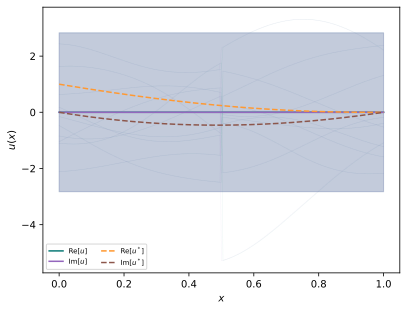

In [8]:
# Plot the prior belief
plotter_complex.plot_belief(
    ax=plt.gca(),
    u=u_prior,
    plot_part="both"
)

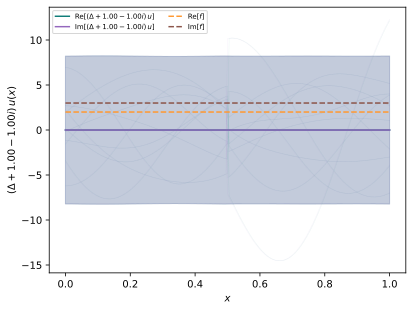

In [9]:
# Plot the prior predictive belief for the Helmholtz operator
plotter_complex.plot_pred_belief(
    ax=plt.gca(),
    u=u_prior,
    plot_part="both"
)

## Observations

In [10]:
# PDE observations
X_pde = domain.uniform_grid((5,), inset=0.1)
Y_pde = np.tile(to_real2(2.0 + 3.0j), (X_pde.shape[0], 1))  # shape (n, 2)

In [11]:
X_bc = np.array([[0.0], [1.0]])
Y_bc = np.vstack([g_left, g_right])

## Posterior (Boundary Values First)

### Conditioning on Boundary Conditions

In [12]:
u_cond_bc = u_prior.condition_on_observations(Y_bc, X=X_bc)

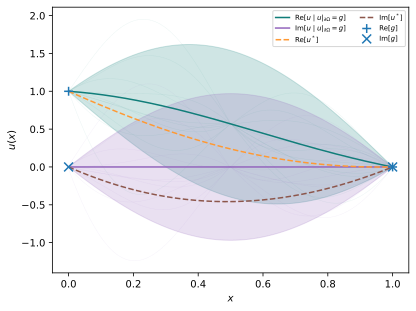

In [13]:
plotter_complex.plot_belief(
    ax=plt.gca(),
    u=u_cond_bc,
    conditioned_on=["bc"],
    plot_part="both"
)

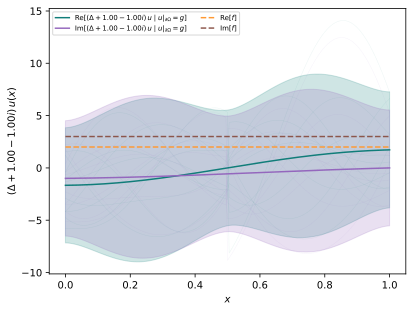

In [14]:
plotter_complex.plot_pred_belief(
    ax=plt.gca(),
    u=u_cond_bc,
    conditioned_on=["bc"],
    plot_part="both"
)

### Conditioning on the PDE

In [15]:
u_cond_bc_pde = u_cond_bc.condition_on_observations(
    Y=Y_pde,
    L=bvp_complex.pde.diffop,
    X=X_pde,
)

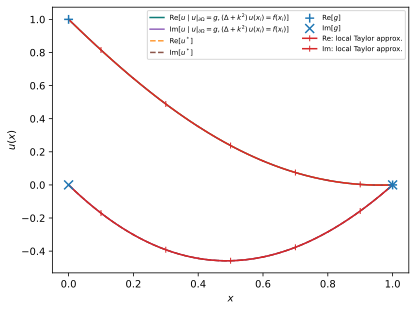

In [16]:
plotter_complex.plot_belief(
    ax=plt.gca(),
    u=u_cond_bc_pde,
    conditioned_on=["bc", "pde"],
    X_pde=X_pde,
    f_X_pde=Y_pde,
    plot_part="both"
)

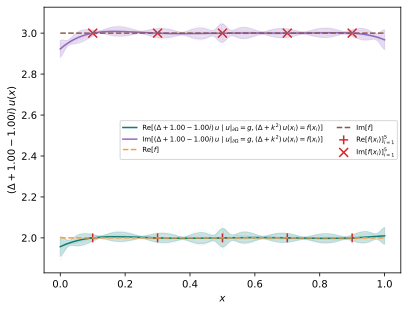

In [17]:
plotter_complex.plot_pred_belief(
    ax=plt.gca(),
    u=u_cond_bc_pde,
    conditioned_on=["bc", "pde"],
    X_pde=X_pde,
    f_X_pde=Y_pde,
    plot_part="both"
)

### Complete Plot

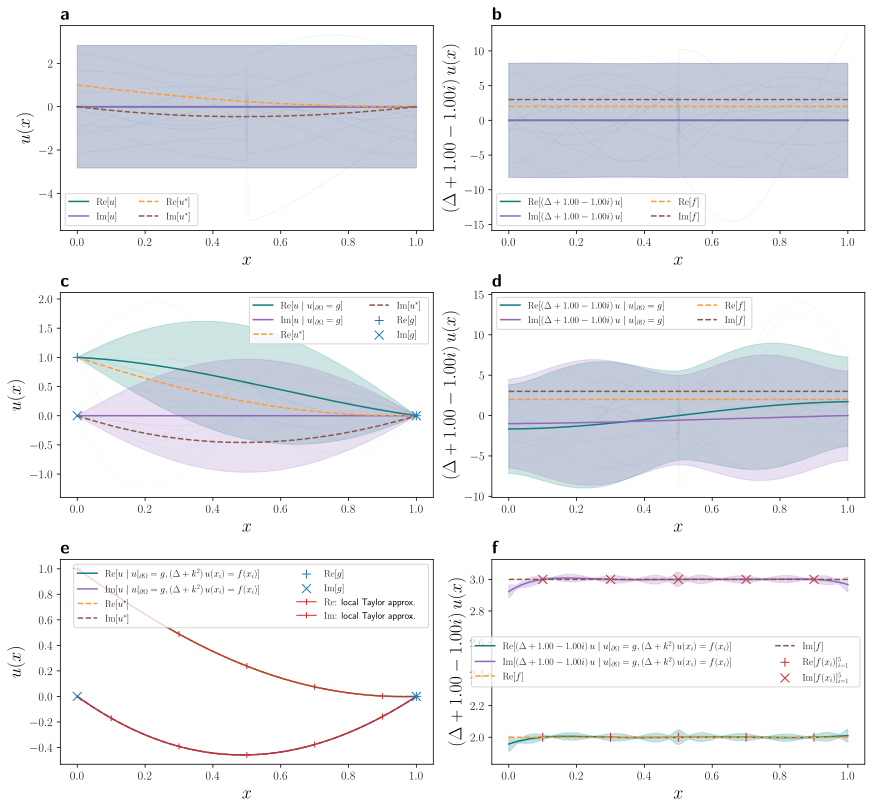

In [18]:
rc = config.tueplots_bundle(nrows=3, ncols=2, rel_width=2.0)
rc.update(
    {
        "lines.linewidth": 1,
        "font.size": 14,
        "axes.labelsize": 18,
        "legend.fontsize": 8,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.titlesize": 18,
    }
)

with plt.rc_context(rc):
    fig, ax = plt.subplots(nrows=3, ncols=2)

    ax[0, 0].set_title(r'\textbf{a}', loc='left', fontweight='bold')

    plotter_complex.plot_belief(
        ax=ax[0, 0],
        u=u_prior,
        plot_part="both"
    )

    ax[0, 1].set_title(r'\textbf{b}', loc='left', fontweight='bold')

    plotter_complex.plot_pred_belief(
        ax=ax[0, 1],
        u=u_prior,
        plot_part="both"
    )

    ax[1, 0].set_title(r'\textbf{c}', loc='left', fontweight='bold')

    plotter_complex.plot_belief(
        ax=ax[1, 0],
        u=u_cond_bc,
        conditioned_on=["bc"],
        plot_part="both"
    )

    ax[1, 1].set_title(r'\textbf{d}', loc='left', fontweight='bold')

    plotter_complex.plot_pred_belief(
        ax=ax[1, 1],
        u=u_cond_bc,
        conditioned_on=["bc"],
        plot_part="both"
    )

    ax[2, 0].set_title(r'\textbf{e}', loc='left', fontweight='bold')

    plotter_complex.plot_belief(
        ax=ax[2, 0],
        u=u_cond_bc_pde,
        conditioned_on=["bc", "pde"],
        X_pde=X_pde,
        f_X_pde=Y_pde,
        plot_part="both"
    )

    ax[2, 1].set_title(r'\textbf{f}', loc='left', fontweight='bold')

    plotter_complex.plot_pred_belief(
        ax=ax[2, 1],
        u=u_cond_bc_pde,
        conditioned_on=["bc", "pde"],
        X_pde=X_pde,
        f_X_pde=Y_pde,
        plot_part="both"
    )

plt.savefig("inHomo_complexHelmholtz_dirichlet_1d_5pts.pdf", bbox_inches='tight')

In [19]:
from typing import List, Dict, Optional
import numpy as np

def compute_metrics(u_pred: np.ndarray, 
                    u_true: np.ndarray,
                    metrics: Optional[List[str]] = None) -> Dict[str, float]:
    if metrics is None:
        metrics = ["mse", "rmse", "mae", "max_error", "relative_l2", "r2"]
    
    u_pred = np.atleast_1d(u_pred).flatten()
    u_true = np.atleast_1d(u_true).flatten()
    
    metric_functions = {
        "mse": lambda yt, yp: np.mean((yt - yp)**2),
        "rmse": lambda yt, yp: np.sqrt(np.mean((yt - yp)**2)),
        "mae": lambda yt, yp: np.mean(np.abs(yt - yp)),
        "max_error": lambda yt, yp: np.max(np.abs(yt - yp)),
        "r2": lambda yt, yp: 1 - np.sum((yt - yp)**2) / np.sum((yt - np.mean(yt))**2),
        "relative_l2": lambda yt, yp: (
            np.linalg.norm(yt - yp) / np.linalg.norm(yt) if np.linalg.norm(yt) > 0 else np.inf
        ),
    }
    
    return {m: metric_functions[m](u_true, u_pred) for m in metrics if m in metric_functions}

# Evaluate GP posterior vs analytical solution
x_test = np.linspace(0.0, 1.0, 1000)

# GP posterior mean in real2 format: shape (N, 2), columns are [Re, Im]
pred_real2 = u_cond_bc_pde.mean(x_test)  # (N, 2)
pred_re = pred_real2[:, 0]
pred_im = pred_real2[:, 1]

# Analytical solution via the existing solution object
u_exact_real2 = solution(x_test)  # shape (N, 2)
true_re = u_exact_real2[:, 0]
true_im = u_exact_real2[:, 1]

# Metrics per component
metrics_re = compute_metrics(pred_re, true_re)
metrics_im = compute_metrics(pred_im, true_im)

# Metrics on the full complex error: |u_pred - u_true| treated element-wise
complex_pred = pred_re + 1j * pred_im
u_exact_complex = true_re + 1j * true_im
complex_error = np.abs(complex_pred - u_exact_complex)
metrics_complex = {
    "mse": np.mean(complex_error**2),
    "rmse": np.sqrt(np.mean(complex_error**2)),
    "mae": np.mean(complex_error),
    "max_error": np.max(complex_error),
    "relative_l2": np.linalg.norm(complex_error) / np.linalg.norm(u_exact_complex),
    "r2": 1 - np.sum(complex_error**2) / np.sum(np.abs(u_exact_complex - np.mean(u_exact_complex))**2),
}

# Print results
def _print_block(title, m):
    print(f"\n  --- {title} ---")
    print(f"    R² Score:            {m['r2']:12.6f}")
    print(f"    MSE:                 {m['mse']:12.6e}")
    print(f"    RMSE:                {m['rmse']:12.6e}")
    print(f"    Mean Absolute Error: {m['mae']:12.6e}")
    print(f"    Maximum Error:       {m['max_error']:12.6e}")
    print(f"    Relative L2 Error:   {m['relative_l2']:12.6e}")

print("=" * 58)
print("EVALUATION METRICS — Complex Helmholtz 1D".center(58))
print(f"  k² = {k_squared:.4f}  (k = {k:.4f})")
print("=" * 58)

_print_block("Real Part", metrics_re)
_print_block("Imaginary Part", metrics_im)

print("\n" + "=" * 58)

        EVALUATION METRICS — Complex Helmholtz 1D         
  k² = 1.0000-1.0000j  (k = 1.0987-0.4551j)

  --- Real Part ---
    R² Score:                1.000000
    MSE:                 2.347684e-10
    RMSE:                1.532215e-05
    Mean Absolute Error: 1.235109e-05
    Maximum Error:       3.432962e-05
    Relative L2 Error:   3.428767e-05

  --- Imaginary Part ---
    R² Score:                1.000000
    MSE:                 6.659375e-10
    RMSE:                2.580576e-05
    Mean Absolute Error: 2.284763e-05
    Maximum Error:       4.979328e-05
    Relative L2 Error:   7.726941e-05

